In [1]:
# pip install scikit-learn --upgrade

In [2]:
import numpy as np
import math as mt
from scipy.stats import norm
from scipy.optimize import curve_fit
from scipy.stats import chisquare
from matplotlib import pyplot as plt
import sklearn

### Simulation of a gaussian fit

In [3]:
def fit_gauss(data, num_bins, a, b, mean, std):
    fig, ax = plt.subplots()
    entries, bin_edges, patches = ax.hist(data, bins = num_bins, range = (a, b), color = 'green', edgecolor = 'black', density = True, label = 'data')
    asse_x = np.resize(bin_edges, bin_edges.size-1) # bin_edges è più lungo di uno rispetto a entries
    best_vals, covar = curve_fit(norm.pdf, asse_x, entries, p0 = (mean, std))
    results = norm.pdf(asse_x, best_vals[0], best_vals[1])
    ax.plot(asse_x, results, '-r', lw = 2, label='fit gauss')
    ax.set_xlabel('x')
    ax.set_ylabel('pdf(x)')
    ax.set_title("fit of a gaussian distributed sample")
    ax.legend(loc = 'upper right')
    plt.show()
    return best_vals, covar

In [4]:
sample = np.random.normal(3.2, 0.7, size=10000)

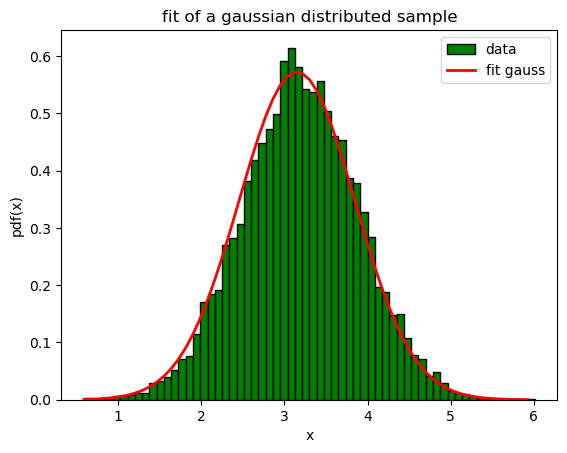

parameters =
 [3.15021894 0.69729949]
covariance matrix =
 [[ 4.75857841e-05 -1.85118819e-10]
 [-1.85118819e-10  3.17243504e-05]]


In [5]:
pars, cov = fit_gauss(sample, "auto", min(sample), max(sample), 0, 1)
print("parameters =\n", pars)
print("covariance matrix =\n", cov)

### Model selection exercize

#### Model Comparison

The distribution of $\ln L$ can only be related to the $\chi^2$ distribution whenever the likelihood is Gaussian. For non-Gaussian likelihoods we can still rank different models in terms of their respectively computed maximum likelihood values, $L^0$. This is only really fair if the models have the same number of parameters.

#### Occam's razor

We need a modified approach whenever the models we're comparing have different numbers of parameters. Such an approach should account for **model complexity** and **effectively penalize models with additional parameters that are not constrained by the data**. This is often called an ***Occam penalty***, because we're trying to incorporate [Occam's Razor](https://www.wikiwand.com/en/Occam%27s_razor#:~:text=Occam's%20razor%2C%20Ockham's%20razor%2C%20Ocham's,is%20usually%20the%20right%20one.).

> *All else being equal (i.e., each model fits the data equally well), the less complex model is favored.*


We'll meet this in extensive detail later, especially in a Bayesian context. But a popular general-purpose tool for model comparison is the **Akaike Information Criterion** (AIC):

$$ \mathrm{AIC}_M \equiv -2\ln[L^0(M)] + 2k + \frac{2k(k+1)}{N-k-1}, $$

where $k$ is the number of model parameters and $N$ is the number of data points.

- For a Gaussian distribution, the first term is equal to $\chi^2$.
- **The model with lowest AIC is the most favored.**
- If all models are equally successful at fitting the data (equal $L^0$ values) then the second and third terms penalize model complexity such that the model with fewest free parameters wins. 
- There is an alternative estimator called BIC ([Schwarz 1978](https://projecteuclid.org/journals/annals-of-statistics/volume-6/issue-2/Estimating-the-Dimension-of-a-Model/10.1214/aos/1176344136.full)). Qualitatively like the AIC

#### Black-hole binary formation channels with gaussian 

You want to figure out how many of formation channels are at play.

The strategy here is to fit a Gaussian Mixture model: this model is a sum of $N$ gaussians each with mean $\mu_j$ and standard deviation $\sigma_j$ and weight $\alpha_j$:

$p(x_i|\theta) = \sum_{j=1}^N \alpha_j \mathcal{N}(\mu_j,\sigma_j) $

This depends on $3N-1$ parameters (not $3N$ because the sum of the $\alpha_j$ must be unity to ensure that this is a probability).

##### Tasks

1) Load this file (`np.load`) and complete a quick exploration of the data. How many modes do you think you see?

2) We'll use `sklearn.mixture.GaussianMixture`. You first need to define the model (instance of a class), and then train it on the data using the `fit` method (the data provided are already in the right numpy format!). This will output the trained model, which has various attributes.

*Note*. We'll do a more formal introduction to scikit-learn in one of the next lectures. Today's exercise is meant to be a formative example on how you might find yourself dealing with a library you've never seen before. This happens *all the time* in research...

3) Complete the fit 10 times with $N=1,...,10$ Gaussians. 

Note: `sklearn` by default will use the so-called [Expectation-Maximization algorithm](https://en.wikipedia.org/wiki/Expectation%E2%80%93maximization_algorithm), which is one of the many great things in data science we don't have time to study in this class.

4) For each of this fits, compute the AIC (easy! It's an attribute of the trained model!). Plot $N$ vs AIC: which model is preferred?

5) Plot the preferred solution on top of the input data. You should get a very nice fit!

6) Understand (i.e. plot) which Gaussian mode corresponds to which part of the input dataset. 

*Hint:* Useful methods here are `score_samples` and `predict_proba`.

In [6]:
file_path = "data_files/formationchannels.npy"

In [7]:
data_bhb = np.load(file_path)
print(data_bhb.shape)

(2950, 1)


In [8]:
vec_data_bhb = data_bhb.transpose()
vec_data_bhb = vec_data_bhb.flatten()
print(vec_data_bhb.shape)

(2950,)


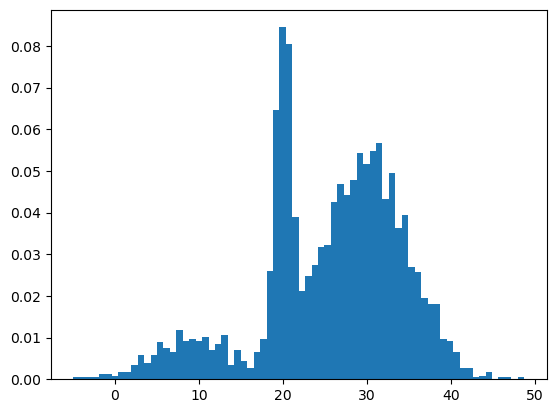

In [9]:
plt.hist(vec_data_bhb, bins=70, density=True)
plt.show()

In [10]:
vec_fit = []
for i in range(1, 11):
  fit = sklearn.mixture.GaussianMixture(n_components=i).fit(data_bhb)
  vec_fit.append(fit)

In [11]:
fit_means = [vec_fit[pos].means_.flatten() for pos in range(len(vec_fit))]
fit_covs = [vec_fit[pos].covariances_.flatten() for pos in range(len(vec_fit))]
fit_weights = [vec_fit[pos].weights_ for pos in range(len(vec_fit))]
fit_AICs = [vec_fit[pos].aic(data_bhb) for pos in range(len(vec_fit))]

In [12]:
best = np.where(fit_AICs == min(fit_AICs))[0][0]
print("NUMBER OF COMPONENTS =",best+1)
print("means:",fit_means[best])
print("covariances:",fit_covs[best])
print("weights:",fit_weights[best])
print("AIC:",fit_AICs[best])
x_axis = np.linspace(min(data_bhb), max(data_bhb), 1000)

NUMBER OF COMPONENTS = 3
means: [30.11424774 20.04958006  9.09732207]
covariances: [24.18811283  1.12483337 21.84261921]
weights: [0.67007695 0.2136368  0.11628626]
AIC: 20082.762831946766


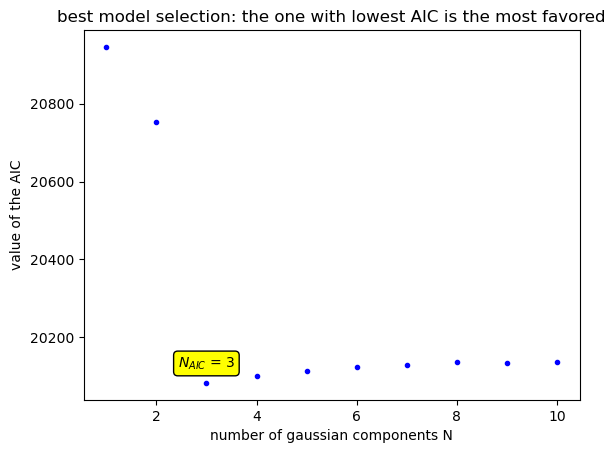

In [16]:
plt.plot(np.arange(1, 11), fit_AICs, ".b")
plt.xlabel("number of gaussian components N")
plt.ylabel("value of the AIC")
plt.title("best model selection: the one with lowest AIC is the most favored")
plt.text(best+1, fit_AICs[best]+50, r"$N_{AIC}$ = "+str(best+1), ha="center", va="center", bbox={"facecolor": "yellow", "edgecolor": "black", "boxstyle": "round"})
plt.show()

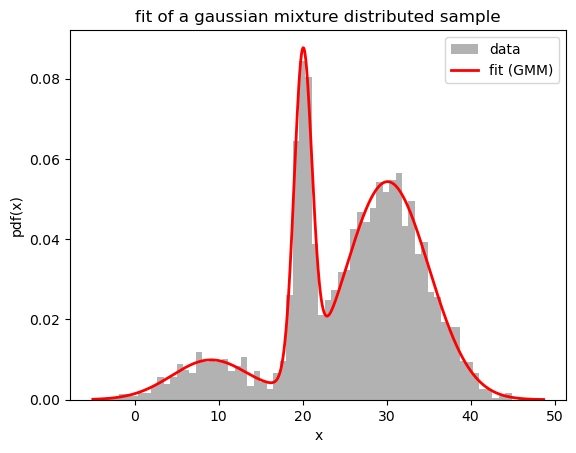

In [14]:
log_prob = vec_fit[best].score_samples(x_axis)  # Log-likelihood della PDF
pdf = np.exp(log_prob)  # Conversione in densità

# Plot dei dati e della PDF stimata
plt.hist(vec_data_bhb, bins=70, density=True, alpha=0.6, color='gray', label="data")
plt.plot(x_axis, pdf, color='red', lw=2, label="fit (GMM)")
plt.xlabel("x")
plt.ylabel("pdf(x)")
plt.title("fit of a gaussian mixture distributed sample")
plt.legend()
plt.show()

##### Notice

The data provided are of shape (N,1), not (N,). This might be confusing at first, but it's the format that sklearn wants (more on this in a future lecture). 

A useful tool to convert between the two is np.newaxis.

In [15]:
x=np.linspace(0, 5, 6)
print(x, x.shape)
print(x[np.newaxis,:], x[np.newaxis,:].shape)
print(x[:,np.newaxis], x[:,np.newaxis].shape)

[0. 1. 2. 3. 4. 5.] (6,)
[[0. 1. 2. 3. 4. 5.]] (1, 6)
[[0.]
 [1.]
 [2.]
 [3.]
 [4.]
 [5.]] (6, 1)
